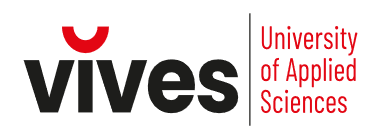<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **A GENTLE INTRODUCTION TO GRADIENT DESCENT**

In this series of exercises we will implement the **Stochastic Gradient Descent** (SGD) algorithm step by step in order to apply **simple linear regression** to a very simple dataset. In the end, two more exercises with more realistic datasets are given, and we will also apply the Scikit-Learn class for linear regression.

The first exercises are based on chapter 3 on linear regression of the textbook ["Grokking Machine Learning"](https://www.manning.com/books/grokking-machine-learning). In [this YouTube video](https://youtu.be/wYPUhge9w5c?si=MGOKg_rK-A2C7kBT), the author, Luis Serrano, summarizes this chapter. The video is highly recommended for students who are not familiar with the mathematical concepts of slope and intercept in a straight line.

## A simple example

As mentioned, we start with a very simple dataset with home prices. You can safely call that the 'Hello World' of the regression in machine learning...

### Exercise 1

Consider the following Pandas `Dataframe`. Explore the data by calling method `describe`, and plot the data in a scatterplot where `x='num_rooms'` and `y='price'`.

In [ ]:
import pandas as pd

# Creating the DataFrame
data = {
    'num_rooms': [1, 2, 3, 5, 6, 7],
    'price': [150, 200, 250, 350, 400, 450]
}

houses = pd.DataFrame(data)

# Display the DataFrame
houses

Now define a function `calculate_price()` that implements the following formula:

```python
price = 100.0 + 50.0 * num_rooms
```

The input argument of the function is the number of rooms `num_rooms`; the return value of the function is the house price `price`.

Use your function to calculate the price of a house having 4 rooms. Add this example to the dataframe and make a new scatterplot using the extended dataframe.

## A second problem

The previous exercise was of course very simple.
Now let's look at a similar but slightly more realistic dataset (although it is still very simple...)

### Exercise 2

Consider the following DataFrame. Again, explore the data, and plot the data in a scatterplot.

Notice that the table now contains a row for a house with 4 rooms, but with the price indicated as `NaN`, which means "Not-a-Number" implying the price is not known. This is called a **missing value**. When plotting, this row is automatically skipped.

Replace the `NaN`-value in your data frame with the price that you have calculated with the function `calculate_price()`. Try to replace the missing value in a smart way; for example, by using [boolean indexing](https://www.geeksforgeeks.org/boolean-indexing-in-pandas/). Make a scatterplot again with the adjusted data frame.

In [ ]:
import numpy as np

# Creating the DataFrame
data = {
    'num_rooms': [1, 2, 3, 4, 5, 6, 7],
    'price': [155.0, 197.0, 244.0, np.NaN, 356.0, 407.0, 448.0]  # NaN stands for Not-a-Number
}

houses = pd.DataFrame(data)

# Display the DataFrame
houses

,num_rooms,price
0,1,155.0
1,2,197.0
2,3,244.0
3,4,NaN
4,5,356.0
5,6,407.0
6,7,448.0


## A first algorithm

In Machine Learning, the objective is to apply an **algorithm** to the dataset that results in a **model** with which we can predict the price of a house with any rooms. Now let's work out such an algorithm step by step!

### Exercise 3

We start by first defining a model ourselves with which we can make **predictions** about the price of a house. The house price is therefore the **target**. In fact, in the previous exercises we have already defined such a model to predict that price using the number of rooms, which we call a **feature**.

Define a function `predict_price()` accepting the following input arguments: `base_price`, `price_per_room`, and `num_rooms`. The base price may be considered as the price of a house without rooms. The output of the function is the `price` of the house, which is calculated as follows:

```python
price = base_price + price_per_room * num_rooms
```

Here, we define a linear model with model parameters `base_price` and `price_per_room`. These parameters are used to map feature `num_rooms` to target `price`. The model can be represented by a straight line described by the following equation:

> $y = ax + b$

In this equation, $x$ is the `num_rooms`, $y$ is the `price`, `base_price` corresponds to **intercept** $b$, and the `price_per_room` to **slope** $a$. Intercept and slope are called the **model parameters**.

Does your function also work with NumPy arrays? Test this out!

### Exercise 4

At first glance, this model already gives quite accurate predictions, but machine learning is about applying algorithms that *learn from the data*, and so we are not supposed to "invent" models ourselves.

In concrete terms, we want to develop an algorithm here that creates a model to make predictions of the price of houses, where those *predictions are as close as possible to the house prices from our dataset*. So we have to develop a **supervised learning** algorithm because the dataset already contains examples of our target, namely the price of the houses.

We start with a simple trick: we adjust the parameters slightly depending on whether the given price is higher or lower than the predicted price. Four cases are considered:

1. If the price of the house is higher than the price the model predicts, and the
number of rooms is positive:
 - add 1 cent to the price per room,
 - add 1 cent to the base price.

2. If the price of the house is higher than the price the model predicts, and the
number of rooms is negative:
 - subtract 1 cent from the price per room,
 - add 1 cent to the base price.

3. If the price of the house is lower than the price the model predicts, and the
number of rooms is negative:
 - add 1 cent to the price per room,
 - subtract 1 cent from the base price.

4. If the price of the house is lower than the price the model predicts, and the
number of rooms is positive:
 - subtract 1 cent from the price per room
 - subtract 1 cent from the base price.

Define a function `simple_trick()` that converts the next algorithm in pseudocode to python code. The input parameters of the function are: `base_price`, `price_per_room`, `num_rooms`, `price`, and `step`. The last parameter is to the default value of 0.01, which corresponds to the 1 cent from the algorithm above. The output is a tuple with the adapted `base_price` and` price_per_room`. Make use of the function `predict_price()` from the previous exercise and test your code!

*Note:* In reality, the number of rooms can never be negative, but mathematically this is possible, and so we must also take into account those unrealistic cases 2 and 3. The figure below portrays the four cases.

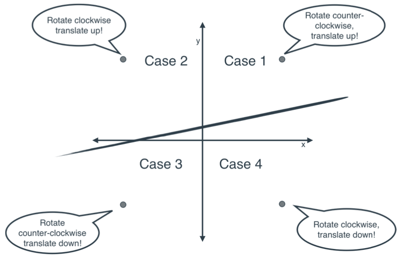

### Exercise 5

The next step is to implement a simple algorithm that uses our simple trick from the previous exercise.

Define a function `simple_algorithm()` that receives a Pandas DataFrame as input with columns `num_rooms` and `price`. This function also has `num_iterations` as input parameter and `step` with 0.01 as default value.

The function first determines a random `base_price` and `price_per_room`. Then it adjusts this `base_price` and `price_per_room` by calling the `simple_trick()` function from the previous exercise. This is repeated `num_iterations` times. The `num_rooms` and `price` input arguments for this function are taken from the dataset, whereby an example (record or row) from this DataFrame is randomly chosen in each iteration.

Pseudocode:

0. *Initialization:* Start with random values ​for the base price and the price per room

1. *Iterations:* Repeat frequently
  - Choose a random house from the dataset
  - Use this data point to adjust the basic price and price per room so that the model predicts the price of the house better

2. *Output:* Return the final base price and price per room
`` `

Now apply the function to the `houses` dataset:

Make a plot of the regression line that the algorithm has found.

## A better algorithm

Our naive algorithm is already working pretty well! But we can do better, because we can apply a mathematical 'trick' and adjust the parameters using the gradient!

### Exercise 6

Define a function `delta_trick()` that does the same as the function `simple_trick()`, but adjusts the parameters as follows:  

```
1) delta = learning_rate * (price - prediction)
2) delta2 = delta * num_rooms
3) price_per_room += delta2
4) base_price += delta
```

The input parameters of the function are: `base_price`, `price_per_room`, `num_rooms`, `price`, and `learning_rate`. The last parameter, the **learning rate**, should have a default value of 0.01, which corresponds to the `step` input argument from the previous algorithm. The output should be a tuple with the updated `base_price` and `price_per_room`.  

Make use of the function `predict_price()` from the previous exercise and test your code!

### Exercise 7

Now define a function `better_algorithm()` that does the same as the function `simple_algorithm()`, but applies the `delta_trick()` function instead of `simple_trick()`.  

The function takes a Pandas DataFrame as input with the columns `num_rooms` and `price`. It also has `num_iterations` as an input parameter, and `learning_rate`, which defaults to 0.01.  

First, a random `base_price` and `price_per_room` are generated. Then, the function updates `base_price` and `price_per_room` `num_iterations` times by calling the `delta_trick()` function from the previous exercise.  

The `num_rooms` and `price` input arguments for this function are taken from the DataFrame, where in each iteration, a **random example** (record or row) from the DataFrame is selected.

Apply the function again to the `houses` dataset:

And make a plot of the regression line that the algorithm has found:

## Mathematical derivation

Actually, the better algorithm from the previous exercise is the **Stochastic Gradient Descent** algorithm, which is also used for training neural networks in deep learning! The mathematical "delta trick" comes down to adjusting the parameters by applying the gradient of the loss function.

The mathemical derivation has already been discussed in the introduction notebook of this topic. Let's briefly recap this here. Recall that the parameters, the slope $a$ and the intercept $b$, are modified during iteration $k$ using the **gradient of the loss function** $L$, which consists of the partial derivates of $L$ with respect to these parameters:

> $a_k = a_{k-1} - \alpha \dfrac{\delta L}{\delta a}$

> $b_k = b_{k-1} - \alpha \dfrac{\delta L}{\delta b}$

with $\alpha$ the learning rate. The loss function $L$ is defined as the sum of squared errors (SSE):

> $L = \dfrac{1}{2}\sum_i(y_i-\hat{y}_i)^2$

with $y_i$ the true target of data point $i$, and $\hat{y}_i$ its prediction defined as:

> $\hat{y}_i = ax_i + b$

where $x_i$ is the feature of data point $i$. Stochastic Gradient Descent uses for each iteration $k$ a random data point $i$ from the dataset to approximate these partial derivatives:

> $\dfrac{\delta L}{\delta a} \approx -(y_i-\hat{y}_i)x_i$

> $\dfrac{\delta L}{\delta b} \approx -(y_i-\hat{y}_i)$

Introducting these approximations into the equations for adjusting $a$ and $b$ gives:

> $a_k = a_{k-1} + \alpha (y_i-\hat{y}_i)x_i$

> $b_k = b_{k-1} + \alpha (y_i-\hat{y}_i)$

If we define $\delta$ as:

> $\delta= \alpha (y_i-\hat{y}_i)$

then we finally get the formulas used in the `delta_trick` function:

> $a_k = a_{k-1} + \delta x_i$

> $b_k = b_{k-1} + \delta$

Recall that in our example $a$ is the `price_per_room`, $b$ is the `base_price`, $x$ is the `num_rooms`, and $y$ is the `price`.




## Final algorithm

In the next exercise, we will write the code of the better algorithm in a more generic way and using the correct machine learning terminology. To do so, we introduce **epochs**: we will still iterate through the data points randomly, but now we will ensure that all data points are covered during a single iteration or epoch. This means we will now have two loops:  
- An *inner loop* that iterates through all data points once in a random order.  
- An *outer loop* that controls the number of epochs.

The **number of epochs** is now also passed as a parameter to the function, and like the learning rate, it is a **hyperparameter**, because it needs to be defined by the user.

### Exercise 8

Now, write a generic function `SGD` that implements the Stochastic Gradient Descent (SGD) algorithm using the concept of *epochs*, as explained above.

Apply this function to the `houses` dataset and plot your results. Also, try to track and plot the progression of the loss function. Can you also create a contour plot of the loss function and draw the path that the SGD algorithm followed to ultimately find the optimal values for `a` and `b`, which correspond to the minimum of the loss function?

### Exercise 9

Apply Stochastic Gradient Descent (SGD) to the `zwift.csv` dataset from the introduction of this topic. Use the obtained model to predict the distance after 2 hours of cycling.

**Attention!** We know that the distance is 0 km after 0 hours of cycling. Therefore, we must fit a straight line that passes through the origin!  

Modify the `SGD()` function to ensure that the regression line always passes through the origin.

Plot the result and the progression of the loss function again.

### Exercise 10

- Read the file 'linkedIn.csv' into a Pandas DataFrame. Using this dataset, you will predict a person's salary based on the number of LinkedIn connections they have.
- Print the first 5 rows of the DataFrame, get a concise summary by calling method `info`, and give the summary statistics by using the `describe` method.
- Make a scatter plot of the data. In Dutch, "loon" means "salary", while "connecties" are the "connections" on LinkedIn.
- Apply Stochastic Gradient Descent (SGD) to fit a straight line through the data points.
- There's a good chance that you'll get an **overflow error**. How does that happen? How could you solve that?
- Plot the evolution of the loss function and print the optimal parameter values derived by SGD.
- Draw the obtained regression line on the scatter plot that you have made earlier.
- Calculate the MSE and the MAE using the data that are not scaled.
- Someone in your circle of friends has 252 connections on LinkedIn. Give an estimate of that person monthly salary.
- Can the real salary of that person be increased by increasing the number of connections on LinkedIn?
- Finally, use Scikit-Learn to fit the data and make the prediction. Do you get the same result? Explain!


---